In [1]:
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

OFFSET = 0.015625

In [ ]:
""" 
Load localiser erp's
"""

loc_path = f"C:/Users/mvmigem/Documents/data/project_2/overlap_corrected/localiser/"
loc_dir_list = glob.glob(loc_path+'/*.csv')
loc_loaded_dfs = []

for p in loc_dir_list:
    df_sub = pd.read_csv(p)
    loc_loaded_dfs.append(df_sub)

df_loc = pd.concat(loc_loaded_dfs,ignore_index=True)
# Drop non EEG channels
df_loc = df_loc[~df_loc['channel'].isin(['eye_above','eye_below','eye_left','eye_right','Status'])]
max_time = .3 # change this depending on the ERP you want to look at
df_loc = df_loc[df_loc['time'] < max_time]

In [ ]:
""" 
Basline correction
"""
baseline_period = df_loc['time'] <0
baseline_means = df_loc[baseline_period].groupby(['subject','channel','position'])['yhat'].mean() #,'visual_field'

df_loc['baseline_corrected'] = df_loc.apply(
    lambda row: row['yhat'] - baseline_means[(row['subject'],row['channel'],row['position'])], #,row['visual_field']
    axis=1
)

In [ ]:
fig, ax = plt.subplots(1)
sns.lineplot(data=df_loc[df_loc['channel'] == "POz"],
            x='time',y='baseline_corrected',
            hue='position',
            errorbar='se')
ax.axhline(y=0, lw=1, c='black' )
ax.axvline(x=0.1, lw=1, c='black' )

In [3]:
""" 
Main data
"""
sub_path = "C:/Users/mvmigem/Documents/data/project_2/overlap_corrected/main/"
dir_list = glob.glob(sub_path+'/*.csv')
loaded_dfs = []
roi_channels = ['Oz','O1','O2',
                'PO3','POz','PO4',
                'P1','Pz','P2',
                'CP1','CPz','CP2',
                'PO8','PO7'
                ]

for p in dir_list:
    df_sub = pd.read_csv(p)
    df_sub = df_sub[df_sub['channel'].isin(roi_channels)]
    loaded_dfs.append(df_sub)

df = pd.concat(loaded_dfs,ignore_index=True)
# Drop non EEG channels
df = df[~df['channel'].isin(['eye_above','eye_below','eye_left','eye_right','Status'])]
max_time = .3 # change this depending on the ERP you want to look at
min_time = -.1
# correct for offset shift
df['time'] = df['time'] - OFFSET
df = df[df['time'] < max_time]
df = df[df['time'] > min_time]


In [4]:
""" 
Basline correction
"""
df = df[df['sequence']==2]
df['visual_field'] = np.where(df['position'].isin([1, 2]), 'up', 'down')
baseline_period = df['time'] <0
baseline_means = df[baseline_period].groupby(['subject','channel','position','feature','attended_feature','unattended_feature'])['yhat'].mean() #,'visual_field'

df['y_bc'] = df.apply(
    lambda row: row['yhat'] - baseline_means[(row['subject'],row['channel'],row['position'],row['feature'],row['attended_feature'],row['unattended_feature'])],axis=1)


In [5]:
peak_prop_path = "C:/Users/mvmigem/Documents/data/project_2/compiled_data/c1_peak_properties.csv"
peak_prop = pd.read_csv(peak_prop_path)
best_pairs = list(zip(peak_prop['subject'], peak_prop['all_pos_peak_channel']))
df['selected_ch'] = df[['subject', 'channel']].apply(tuple, axis=1).isin(best_pairs)

In [6]:
df['abs_base'] = df['y_bc'].abs()
df['abs_norm'] = df['yhat'].abs()

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_44520\4090365220.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'angle'][df['visual_field']==side],
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_44520\4090365220.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'angle'][df['visual_field']==side],
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_44520\4090365220.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'angle'][df['visual_field']=='down'],
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_44520\4090365220.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'angle'][df['visual_field']=='down'],


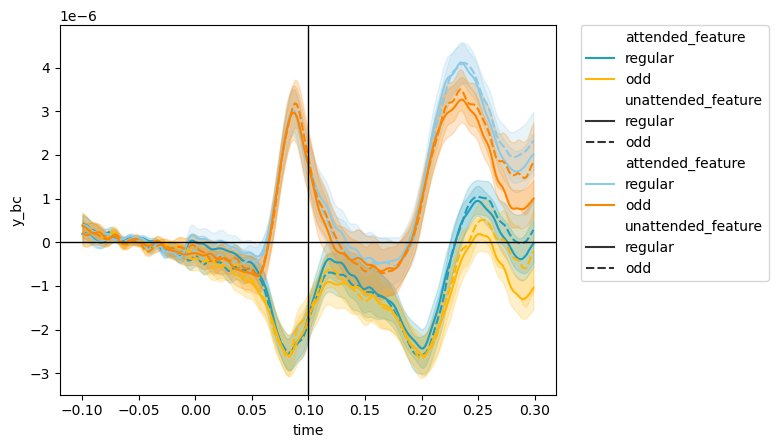

In [9]:
line_colours1= ['#219EBC','#FFB703']
line_colours2 = ['#8ECAE6','#FB8500',]
line_colours = ['#219EBC','#FFB703','#8ECAE6','#FB8500']

df = df[df['sequence']==2]
df['visual_field'] = np.where(df['position'].isin([1, 2]), 'up', 'down')

side = 'up'
y = 'y_bc'

fig, ax = plt.subplots(1,1,sharey=False,sharex=False)
sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'angle'][df['visual_field']==side],
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')
sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'angle'][df['visual_field']=='down'],
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours2,
            errorbar='se')
# sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'rotation'][df['visual_field']==side],
#             x='time',y= y,
#             hue='attended_feature',style= 'unattended_feature',
#             palette=line_colours1,
#             errorbar='se')
# sns.lineplot(data=df[df['selected_ch']][df['feature'] == 'rotation'][df['visual_field']=='down'],
#             x='time',y= y,
#             hue='attended_feature',style= 'unattended_feature',
#             palette=line_colours2,
#             errorbar='se')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=0, lw=1, c='black' )
ax.axvline(x=0.1, lw=1, c='black' )
# ax[1].axhline(y=0, lw=1, c='black' )
# ax[1].axvline(x=0.1, lw=1, c='black' )

In [11]:
subject_list = df['subject'].unique()

In [ ]:
""" 
Select the C1 to analyse
"""
peak_properties = pd.read_csv(r'C:\Users\mvmigem\Documents\data\project_1\compiled_dataframes\c1_peak_properties.csv')
##  C1 time window
# Window search
c1_tmin = 0.06
c1_tmax = 0.09
c1_timwid = 0.01
c1_sampwid = int(c1_timwid*512)

winidx_c1 = []

subject_list = df['subject'].unique()

indexes_peak = []
for sub in subject_list:
    sub_df = df[df['subject']== sub]
    peak_time = peak_properties[peak_properties['subject'] == sub]['all_pos_peak_latency'].iloc[0]
    peak_indx = np.array(sub_df[sub_df['time'] == peak_time]['index'])
    indexes_peak = np.concatenate([indexes_peak,peak_indx],axis=0)
# Select window around it
winidx_c1_n = []
for i, idx in enumerate(indexes_peak):
    win_li = np.arange(idx - c1_sampwid, idx + c1_sampwid +1)
    winidx_c1_n = np.concatenate([winidx_c1_n,win_li],axis=0)
winidx_c1.append(winidx_c1_n)

winidx_c1_1 = winidx_c1[0].astype(int)
# Apply to df
c1_win_df_1 = df[df['index'].isin(winidx_c1_1)]
c1_means_df_1 = c1_win_df_1.groupby(['subject','attention','expectation','visual_field'])['baseline_corrected'].mean().reset_index()


C:\Users\mvmigem\AppData\Local\Temp\ipykernel_44520\294532433.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df['channel'].isin(["PO8","PO4","O2","PO8","PO4","O2"])][df['feature'] == "angle"],
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_44520\294532433.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df['channel'].isin(["PO8","PO4","O2","PO8","PO4","O2"])][df['feature'] == "rotation"],


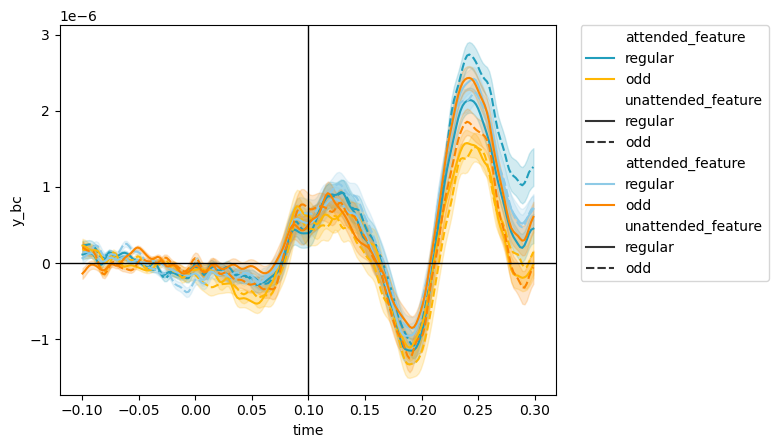

In [10]:
df['visual_field'] = np.where(df['position'].isin([1, 2]), 'up', 'down')

line_colours1= ['#219EBC','#FFB703']
line_colours2 = ['#8ECAE6','#FB8500',]

side = 'down'
y = 'y_bc'

fig, ax = plt.subplots(1)

sns.lineplot(data=df[df['channel'].isin(["PO8","PO4","O2","PO8","PO4","O2"])][df['feature'] == "angle"],
            x='time',y=y,
            hue='attended_feature',style='unattended_feature',
            palette=line_colours1,
            errorbar='se')
sns.lineplot(data=df[df['channel'].isin(["PO8","PO4","O2","PO8","PO4","O2"])][df['feature'] == "rotation"],
            x='time',y=y,
            hue='attended_feature',style='unattended_feature',
            palette=line_colours2,
            errorbar='se')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=0, lw=1, c='black' )
ax.axvline(x=0.1, lw=1, c='black' )
